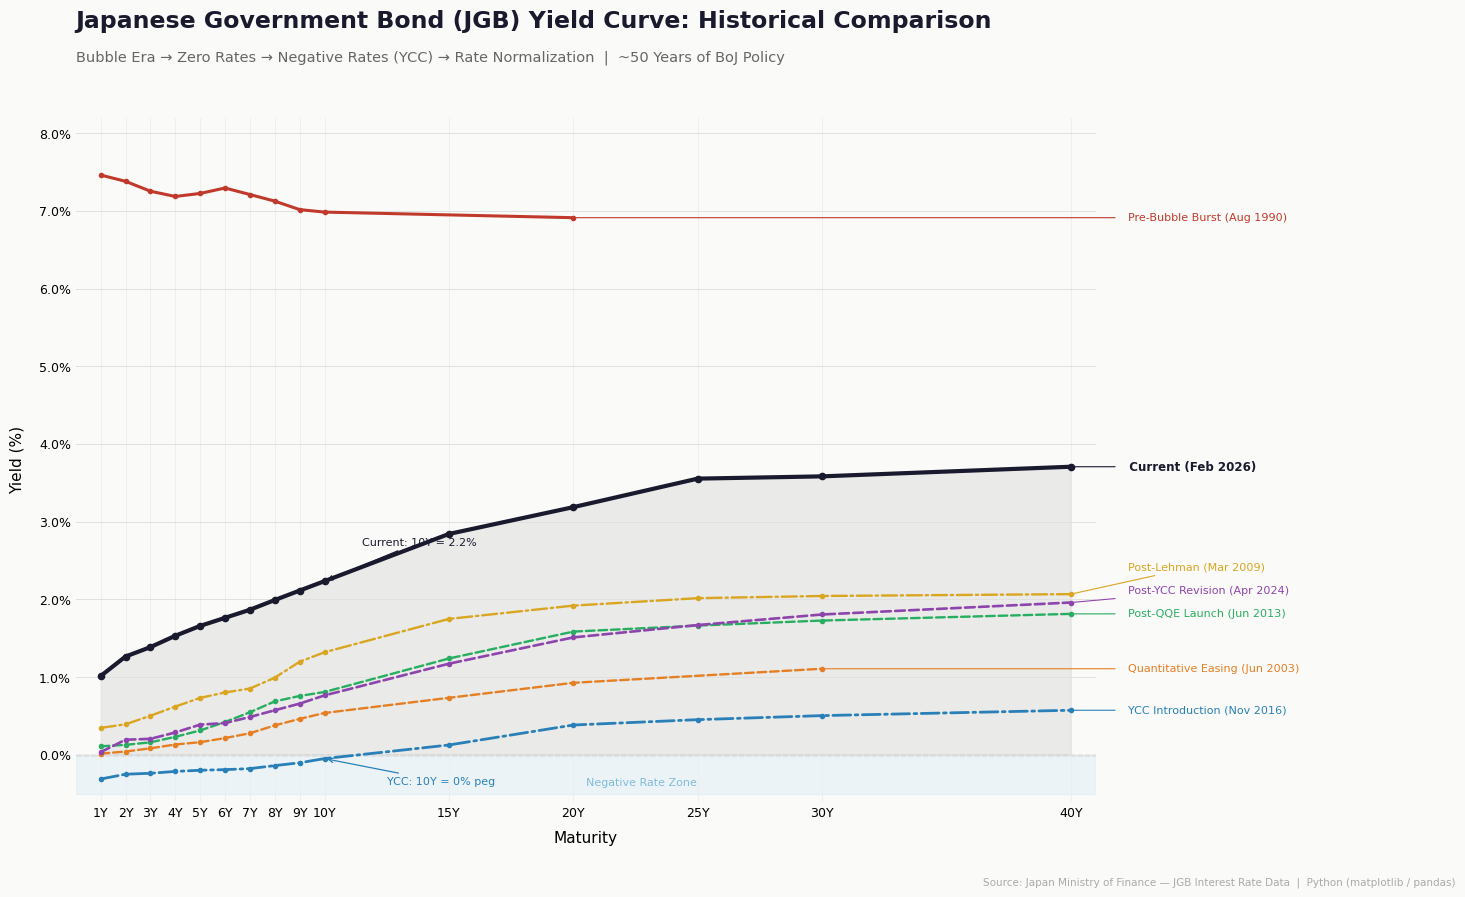

In [10]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re

# ── Load Data ──────────────────────────────────────────────────────
df = pd.read_csv(
    '~/Downloads/jgbcm_all.csv',
    encoding='shift_jis',
    skiprows=1,
    header=0,
    names=['date','1y','2y','3y','4y','5y','6y','7y','8y','9y',
           '10y','15y','20y','25y','30y','40y']
)

# ── Convert Japanese Era Dates → Gregorian ─────────────────────────
def era_to_date(s):
    """S=Showa, H=Heisei, R=Reiwa → datetime"""
    m = re.match(r'^([SHR])(\d+)\.(\d+)\.(\d+)$', str(s))
    if not m:
        return None
    era, yr, mo, da = m.group(1), int(m.group(2)), int(m.group(3)), int(m.group(4))
    base = {'S': 1925, 'H': 1988, 'R': 2018}
    try:
        return pd.Timestamp(year=base[era] + yr, month=mo, day=da)
    except:
        return None

df['dt'] = df['date'].apply(era_to_date)
df = df.dropna(subset=['dt']).set_index('dt').sort_index()

mats = ['1y','2y','3y','4y','5y','6y','7y','8y','9y','10y','15y','20y','25y','30y','40y']
for c in mats:
    df[c] = pd.to_numeric(df[c], errors='coerce')

x_vals = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 40]

# ── Curve Definitions ─────────────────────────────────────────────
# (label, year-month, color, linestyle, linewidth)
CURVES = [
    ('Pre-Bubble Burst (Aug 1990)', '1990-08', '#C0392B', '-',   2.2),
    ('Quantitative Easing (Jun 2003)', '2003-06', '#E67E22', '--', 1.7),
    ('Post-Lehman (Mar 2009)',      '2009-03', '#DAA520', '-.',  1.7),
    ('Post-QQE Launch (Jun 2013)',  '2013-06', '#27AE60', '--',  1.7),
    ('YCC Introduction (Nov 2016)', '2016-11', '#2980B9', '-.',  2.0),
    ('Post-YCC Revision (Apr 2024)','2024-04', '#8E44AD', '--',  1.9),
    ('Current (Feb 2026)',          '2026-02', '#1A1A2E', '-',   3.0),
]

# ── Figure ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 9), facecolor='#FAFAF8')
ax = fig.add_axes([0.07, 0.10, 0.68, 0.76])
ax.set_facecolor('#FAFAF8')

# Shade negative rate zone
ax.axhspan(-0.5, 0, color='#AED6F1', alpha=0.18, zorder=0)
ax.axhline(0, color='#AAAAAA', lw=1.0, ls='--', zorder=1)
ax.text(0.5, 0.02, 'Negative Rate Zone', fontsize=8, color='#7FBBDB',
        transform=ax.transAxes, va='bottom')

curve_data = []
for (label, ym, color, ls, lw) in CURVES:
    row = df.loc[ym].iloc[0]
    valid = [(x, row[m]) for x, m in zip(x_vals, mats) if not np.isnan(row[m])]
    if not valid:
        continue
    xv, yv = zip(*valid)
    curve_data.append((label, xv, yv, color, ls, lw))

    if label.startswith('Current'):
        ax.fill_between(xv, 0, yv, alpha=0.07, color=color, zorder=0)

    ax.plot(xv, yv, color=color, lw=lw, ls=ls,
            marker='o', markersize=4.5 if label.startswith('Current') else 3,
            zorder=3 if label.startswith('Current') else 2,
            label=label,
            solid_capstyle='round', dash_capstyle='round')

# ── Right-side Labels (spaced to avoid overlap) ───────────────────
endpoints = [(yv[-1], label, xv[-1], color)
             for (label, xv, yv, color, ls, lw) in curve_data]
endpoints.sort(key=lambda x: x[0])

adj_y = [e[0] for e in endpoints]
min_gap = 0.30
for i in range(1, len(adj_y)):
    if adj_y[i] - adj_y[i-1] < min_gap:
        adj_y[i] = adj_y[i-1] + min_gap

for (orig_y, label, xe, color), ay in zip(endpoints, adj_y):
    bold = label.startswith('Current')
    ax.annotate(
        f"  {label}",
        xy=(xe, orig_y),
        xytext=(42, ay),
        fontsize=8.5 if bold else 8.0,
        color=color,
        fontweight='bold' if bold else 'normal',
        va='center', ha='left',
        arrowprops=dict(arrowstyle='-', color=color, lw=0.8),
        annotation_clip=False
    )

# ── Axes ──────────────────────────────────────────────────────────
ax.set_xlim(0, 41)
ax.set_ylim(-0.6, 8.2)
ax.set_xticks(x_vals)
ax.set_xticklabels([f"{x}Y" for x in x_vals], fontsize=9)
ax.set_ylabel('Yield (%)', fontsize=11, labelpad=10)
ax.set_xlabel('Maturity', fontsize=11, labelpad=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.tick_params(axis='both', length=0, labelsize=9)
ax.grid(axis='y', color='#E0E0E0', lw=0.7, zorder=0)
ax.grid(axis='x', color='#EBEBEB', lw=0.5, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# ── Callout Annotations ───────────────────────────────────────────
ax.annotate('YCC: 10Y = 0% peg', xy=(10, -0.048), xytext=(12.5, -0.38),
            fontsize=8, color='#2980B9',
            arrowprops=dict(arrowstyle='->', color='#2980B9', lw=0.9))
ax.annotate('Current: 10Y = 2.2%', xy=(10, 2.235), xytext=(11.5, 2.7),
            fontsize=8, color='#1A1A2E',
            arrowprops=dict(arrowstyle='->', color='#1A1A2E', lw=0.9))

# ── Title & Footer ────────────────────────────────────────────────
fig.text(0.07, 0.98,
         'Japanese Government Bond (JGB) Yield Curve: Historical Comparison',
         fontsize=17, fontweight='bold', color='#1A1A2E', va='top')
fig.text(0.07, 0.935,
         'Bubble Era → Zero Rates → Negative Rates (YCC) → Rate Normalization  |  ~50 Years of BoJ Policy',
         fontsize=10.5, color='#666666', va='top')
fig.text(0.99, 0.005,
         'Source: Japan Ministry of Finance — JGB Interest Rate Data  |  Python (matplotlib / pandas)',
         fontsize=7.5, color='#AAAAAA', ha='right', va='bottom')

plt.savefig("japan_yieldcurve_plot.png")
plt.show()

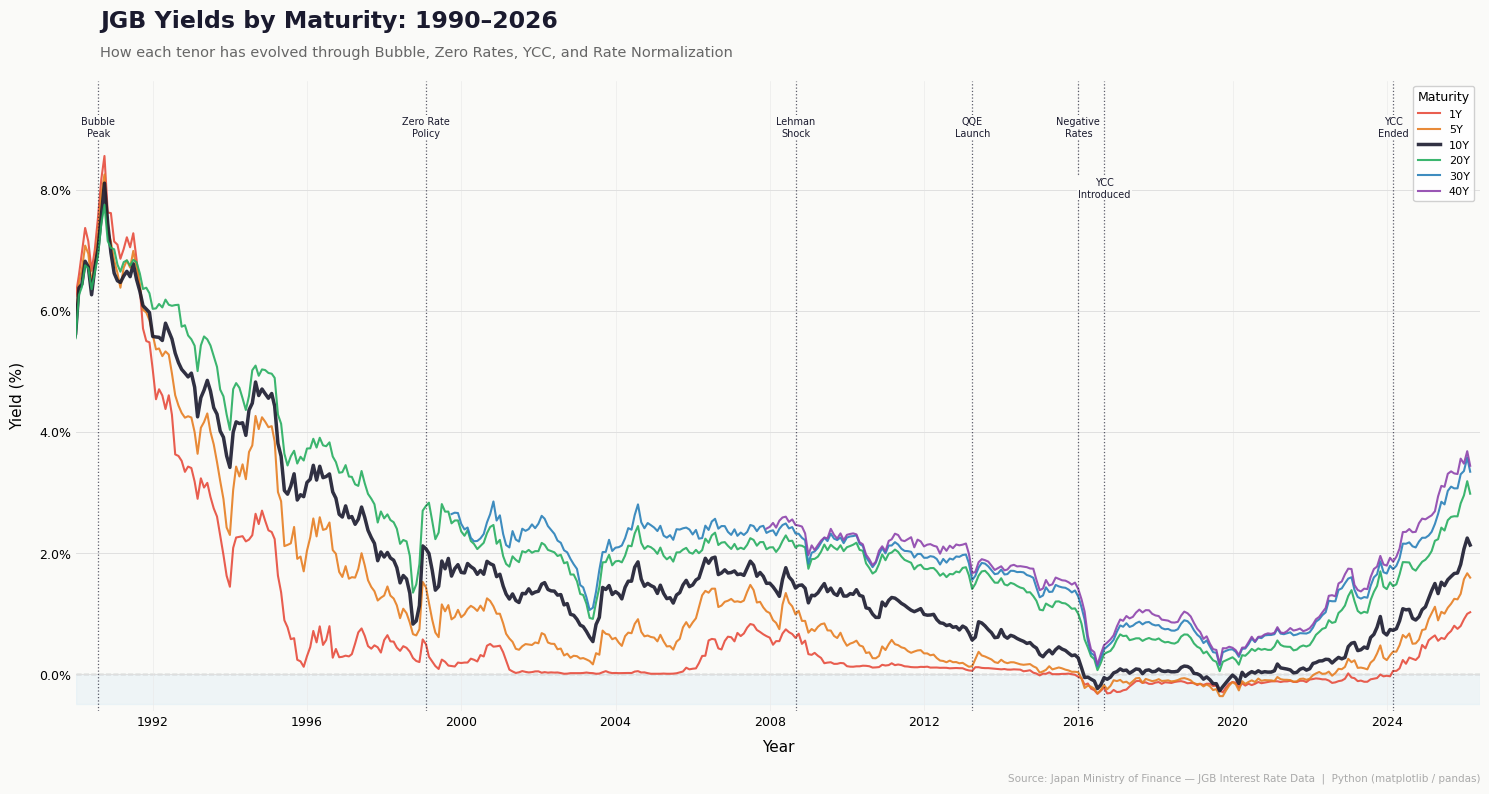

In [31]:
# ── 表示する年限を選択（全部入れると線が多すぎるので代表値）──────
MATURITIES = {
    '1Y':  '1y',
    '5Y':  '5y',
    '10Y': '10y',
    '20Y': '20y',
    '30Y': '30y',
    '40Y': '40y',
}

COLORS = {
    '1Y':  '#E74C3C',
    '5Y':  '#E67E22',
    '10Y': '#1A1A2E',  # 10年は太く・濃く（最重要指標）
    '20Y': '#27AE60',
    '30Y': '#2980B9',
    '40Y': '#8E44AD',
}

# ── 月次にリサンプリング（ノイズ軽減・描画速度向上）──────────────
df_monthly = df[list(MATURITIES.values())].resample('ME').last()

# ── Figure ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 8), facecolor='#FAFAF8')
ax.set_facecolor('#FAFAF8')

# マイナス金利領域をハイライト
ax.axhspan(-0.5, 0, color='#AED6F1', alpha=0.15, zorder=0)
ax.axhline(0, color='#AAAAAA', lw=1.0, ls='--', zorder=1)

for label, col in MATURITIES.items():
    series = df_monthly[col].dropna()
    lw = 2.5 if label == '10Y' else 1.5
    ax.plot(series.index, series.values,
            color=COLORS[label], lw=lw, label=label,
            alpha=0.9)

# ── 主要イベントの縦線 ────────────────────────────────────────────
EVENTS = [
    ('1990-08', 'Bubble\nPeak',        '#1A1A2E', 9.2),
    ('1999-02', 'Zero Rate\nPolicy',   '#1A1A2E', 9.2),
    ('2008-09', 'Lehman\nShock',       '#1A1A2E', 9.2),
    ('2013-04', 'QQE\nLaunch',         '#1A1A2E', 9.2),
    ('2016-01', 'Negative\nRates',     '#1A1A2E', 9.2),
    ('2016-09', 'YCC\nIntroduced',     '#1A1A2E', 8.2),
    ('2024-03', 'YCC\nEnded',          '#1A1A2E', 9.2),
]

for date_str, label, color, y_pos in EVENTS:
    x = pd.Timestamp(date_str)
    ax.axvline(x, color=color, lw=0.9, ls=':', alpha=0.7, zorder=2)
    ax.text(x, y_pos, label, fontsize=7, color=color,
            ha='center', va='top', rotation=0,
            bbox=dict(fc='#FAFAF8', ec='none', pad=1))

# ── 凡例 ─────────────────────────────────────────────────────────
ax.legend(title='Maturity', fontsize=8, title_fontsize=9,
          frameon=True, framealpha=0.9, edgecolor='#CCCCCC',
          loc='upper right')

# ── 軸設定 ────────────────────────────────────────────────────────
ax.set_xlim(pd.Timestamp('1990-01'), pd.Timestamp('2026-06'))
ax.set_ylim(-0.6, 9.8)
ax.set_ylabel('Yield (%)', fontsize=11, labelpad=10)
ax.set_xlabel('Year', fontsize=11, labelpad=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.tick_params(axis='both', length=0, labelsize=9)
ax.grid(axis='y', color='#E0E0E0', lw=0.7, zorder=0)
ax.grid(axis='x', color='#EBEBEB', lw=0.5, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# ── タイトル・フッター ─────────────────────────────────────────────
fig.text(0.07, 0.97,
         'JGB Yields by Maturity: 1990–2026',
         fontsize=17, fontweight='bold', color='#1A1A2E', va='top')
fig.text(0.07, 0.925,
         'How each tenor has evolved through Bubble, Zero Rates, YCC, and Rate Normalization',
         fontsize=10.5, color='#666666', va='top')
fig.text(0.99, 0.005,
         'Source: Japan Ministry of Finance — JGB Interest Rate Data  |  Python (matplotlib / pandas)',
         fontsize=7.5, color='#AAAAAA', ha='right')

plt.tight_layout(rect=[0, 0.02, 1, 0.90])
plt.savefig("japan_yieldcurve_bymaturity.png")
fig